In [1]:
## simple notebook to compare particle contens of different runs, for signal injected

In [2]:
pmodelsfiles = '../rundir_fake_stops1/all_hiscores/hiscores*.dict'
outfile = 'highScores_stops'
truthfile = '../rundir_fake_stops1/truth.dict'
nmodels = 10

In [3]:
# the imports

import sys,os,copy,glob
import numpy as np
sys.path.append(os.path.abspath('../smodels'))
sys.path.append(os.path.abspath('../'))
from builder.protomodel import ProtoModel
from builder.manipulator import Manipulator
from tester.predictor import Predictor
from tester.combiner import Combiner
from walker.hiscores import Hiscores
from smodels.experiment.databaseObj import Database
from smodels.base.physicsUnits import fb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from names import particleLabels
from sparticleNames import SParticleNames

In [4]:
# setting up the style
# sns.set() #Set style
# sns.set_style('ticks')
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=2.0)
# sns.set_palette(sns.color_palette("Paired"))
sns.set_palette(sns.color_palette("deep"))
from smodels.base import smodelsLogging
smodelsLogging.setLogLevel('error')

In [5]:
#Set colors:
allPids = [1000022, 1000006, 1000001, 1000021, 1000012, 1000023, 
            1000013, 2000006, 1000011, 1000005, 1000014, 1000004, 1000015, 1000016, 1000024]
namer = SParticleNames ( susy = False )
colors = sns.color_palette('deep',n_colors=len(namer.xIDs))

#Replace default colors:
for pid in sorted(namer.xIDs.keys()):
    if not pid in allPids:
        allPids.append(pid)
colorDict = dict(zip(allPids,colors))
colorDict[1000002] = colorDict[1000001]
colorDict[1000003] = colorDict[1000001]
colorDict[1000004] = colorDict[1000001]

In [6]:
def getLikelihoods(protomodel,muvals,normalize=True):
    
    #Sort tpList
    critic = sorted(protomodel.tpList, key = lambda tp: tp[0], reverse = True)[0][2]

    #Combiner likelihood:
    combiner = Combiner(0)
    llhComb = np.array([combiner.getCombinedLikelihood(protomodel.bestCombo,mu) for mu in muvals])
    llhCombSM = combiner.getCombinedLikelihood(protomodel.bestCombo,0.)
    llhDict = {'Combined' : llhComb}
    llhDictSM = {'Combined' : llhCombSM}
    for tp in protomodel.bestCombo:
        llhDict[tp.expResult.globalInfo.id] = np.array([tp.getLikelihood(mu) for mu in muvals])
        llhDictSM[tp.expResult.globalInfo.id] = tp.getLikelihood(0.0)

    #Critic likelihood:
    if critic.getLikelihood(1.0) is not None:
        llhDictSM['Critic'] = critic.getLikelihood(0.0)
        llhDict['Critic'] = np.array([critic.getLikelihood(mu) for mu in muvals])
    else:
        llhDict['Critic'] = None
        llhDictSM['Critic'] = None
    llhDict['SM values'] = llhDictSM
    
    #Compute normalizations:
    if normalize:
        for key,llhd in llhDict.items():
            if key != 'SM values':
                norm = llhd.sum()
                llhDict[key] = llhd/norm
                llhDict['SM values'][key] *= 1/norm
    
    
    return llhDict


In [7]:
def fromDict(inputDict):
    
    p = ProtoModel(walkerid=0)
    for key,v in inputDict.items():
        setattr(p,key,copy.deepcopy(v))
        
    return p

In [8]:
pBest = None

In [9]:
#Get highest score from each run:
protomodelsDict = {}
for ff in glob.glob(pmodelsfiles):
    with open(ff,'r') as f:
        pList = eval(f.read())
    run = int(os.path.basename(ff).replace('hiscores','').replace('.dict',''))
    #print ( f"pDict {list(pList)[0]}" )
    #pList = [fromDict(pDict) for pDict in pList[:]]
    p = sorted(pList, key = lambda p: p["K"], reverse=True)[0]
    protomodelsDict[run] = pList[0]
    if pBest is None or pBest["K"] < p["K"]:
        pBest = p
    

In [10]:
pTrue = None
with open ( truthfile, "rt" ) as f:
    pTrue = eval(f.read())

In [11]:
#Get all particles which appears in all models:
particles = []
modelList = list(protomodelsDict.items())
modelList = sorted(modelList, key = lambda pt: pt[0])
modelList = [[-0.75,pTrue]] + modelList[:] #Add winning protomodel as run 0
modelList = np.array(modelList)
runs = modelList[:nmodels+1,0]
modelList = modelList[:nmodels+1,1]
for p in modelList:
    particles += list(p["masses"].keys())
particles = list(set(particles))

#Build useful dataset:
nparticles = np.array([len(p["masses"].keys() ) for p in modelList])
Kvalues = np.array([p["K"] if (p["K"] and p["K"] > 0) else 0.0 for p in modelList])
Zvalues = np.array([p["TL"] if (p["TL"] and p["TL"] > 0) else 0.0 for p in modelList])
masses = dict([[pid,[]] for pid in particles])
for p in modelList:
    for pid in masses:
        if pid in p["masses"]:
            masses[pid].append(p["masses"][pid])
        else:
            masses[pid].append(-100.0)
for pid in masses:
    masses[pid] = np.array(masses[pid])
dataDict = {'run' : runs, 'K' : Kvalues,
                   'nparticles' : nparticles}
dataDict.update(masses) 
df = pd.DataFrame(dataDict)

In [12]:
for run in sorted(protomodelsDict.keys()):
    print( f'run={run} K={protomodelsDict[run]["K"]}, step={protomodelsDict[run]["step"]}' )

Karr = np.array([p["K"] for p in protomodelsDict.values()])
Kavg = Karr.mean()
Kstd = Karr.std()
Kmin = min ( Karr )
print('K (avg) = %1.2f +- %1.2f' %(Kavg,Kstd))

run=1 K=47.171517, step=1214
run=2 K=57.338055, step=2044
run=3 K=59.208382, step=1731
run=4 K=58.733462, step=3462
run=5 K=59.083243, step=240
run=6 K=60.384748, step=2209
run=7 K=59.0959, step=1289
run=8 K=59.578734, step=1811
run=9 K=59.176674, step=1865
run=10 K=54.356837, step=2291
run=11 K=58.348057, step=2285
run=12 K=57.389539, step=2686
run=13 K=59.975396, step=1399
run=14 K=57.652378, step=314
run=15 K=60.053929, step=2072
run=16 K=60.264267, step=311
run=17 K=59.496072, step=1042
run=18 K=59.508825, step=242
run=19 K=59.512102, step=2249
run=20 K=56.195787, step=6349
K (avg) = 58.13 +- 2.90


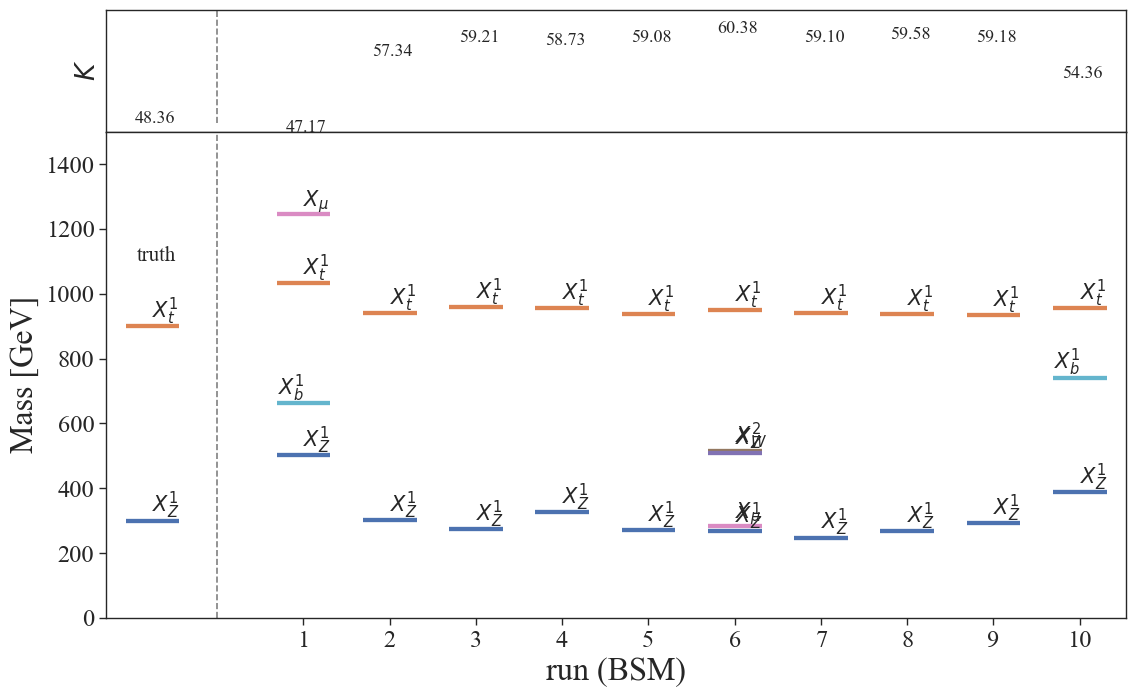

In [13]:
f, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[1, 4]},figsize=(12,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0)

nsteps = 10

axarr[0].scatter(df['run'],df['K'],s=80,c='gray')
axarr[0].set_ylabel(r'$K$')
axarr[0].set_ylim(1.0,15.0)
axarr[0].set_yticks([])
for i,row in df.iterrows():
    axarr[0].annotate(rf'{row["K"]:1.2f}',(runs[i]-.2,(row["K"]-Kmin)/Kstd*2.5 + 1),fontsize=13)
#    axarr[0].annotate(r'$%1.2f$' %row['K'],(row['run']-0.2,row['K']+0.8),fontsize=13)


axarr[0].vlines(x=0,ymin=2,ymax=15,linestyle='--',color='gray')

for pid in masses.keys():
    if not pid in masses: #Skip particles present in real run, but not the fakes
        continue
    data = df
    sns.scatterplot(x=data['run'],y=data[pid], size=1000,sizes=(1500,1500),marker='_',
                    label=r'$%s$' %(particleLabels[pid]), legend=False,
                    color=[colorDict[pid]],ax=axarr[1])
    for i,m in enumerate(masses[pid]):
        if m < 0: continue
        if 'b' in particleLabels[pid]:
            axarr[1].annotate(r'$%s$' %(particleLabels[pid]),(runs[i]-0.3,m+25.),fontsize=15)
        else:
            axarr[1].annotate(r'$%s$' %(particleLabels[pid]),(runs[i],m+25.),fontsize=15)
axarr[1].set_ylim(0.,1500.0)
axarr[1].set_xlabel('run (BSM)', fontsize=23)
axarr[1].set_ylabel('Mass [GeV]', fontsize=23)
axarr[1].set_xticks(np.arange(1,df['run'].max()+1))
axarr[1].vlines(x=0,ymin=0,ymax=1500,linestyle='--',color='gray')
#     plt.plot(df['run'],m,'-',linewidth=2)

axarr[1].text(-0.7,1100,'truth',fontsize=15,horizontalalignment='center')
plt.ylim(0.,1500.0)



# plt.grid(axis='x') 
# plt.legend(loc=(0.8,0.85),framealpha=1.0,ncol=3,labelspacing=0.1,
#            handlelength=0.4,handletextpad=0.35,markerscale=0.8,columnspacing=1.0)
# plt.tight_layout()
plt.savefig(outfile+".pdf")
plt.savefig(outfile+".png")
plt.show()

In [14]:
len(df)

11